In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from numba import jit
import math

# time grid
t = np.linspace(0,3,200)

# starting points
z_values = np.linspace(0,150,200)

In [7]:

@jit
def solve_pde_flux_form(
    z, dz, dt, time_steps, Nx,
    Da, alpha,
    D1, U1, k1, IC_B
):
    #print("1. initializing")
    #A = IC_A.copy()
    lambda_ = np.sqrt(alpha / Da)
    A= np.exp(-lambda_*z)
    B1 = IC_B.copy()

    #A_new = np.zeros(Nx)
    B1_new = np.zeros(Nx)

    # Time steop loop
    inv_dz2 = 1.0 / (dz * dz)
    inv_dz = 1.0 / dz
   
    #print("2. Starting the time looop")
    for n in range(time_steps):
        # spatial loop
        B1_new[0]  = 0#(D1[0] / (D1[0] + U1[0]*dz)) * B1_new[1]
        for j in range(1, Nx-1):
            # A
            #diff_A = Da * (A[j-1] - 2*A[j] + A[j+1]) * inv_dz2 
            #A_new[j] = A[j] + dt * (diff_A - alpha * A[j])

            # B1
            diff_B1 = D1[j] * (B1[j-1] - 2*B1[j] + B1[j+1]) *inv_dz2
            # Advection
            # Fluxes
            U_left  = 0.5*(U1[j] + U1[j-1])
            U_right = 0.5*(U1[j] + U1[j+1])

            # Upwind flux left face
            if U_left > 0:
                F_left = U_left * B1[j-1]
            else:
                F_left = U_left * B1[j]

            # Upwind flux right face
            if U_right > 0:
                F_right = U_right * B1[j]
            else:
                F_right = U_right * B1[j+1]

            adv_B1 = -(F_right - F_left) * inv_dz

            B1_new[j] = B1[j] + dt * (diff_B1 + adv_B1 + alpha*A[j] - k1 * B1[j])
        # Imposing the boundary conditions after a spatial loop
        # A BCs
        #A_new[0] = 1.0
        #A_new[-1] = 0.0

        # B1 BCs 
        B1_new[0] = B1_new[1]
        B1_new[-1] = 0


        for j in range(Nx):
            
            B1[j] = B1_new[j]

    
    #print("3. Done with time loop.")
    return  A, B1


In [ ]:
L=150
Nx = 5000
z = np.linspace(0,150,Nx)

Dz = L/(Nx-1)
a = 61/50
alpha = 1.74
Da = 1
lambda_ = np.sqrt(alpha/Da)
#u = 185 - a*z
u = 10**(-2)+(3.66*10**4)/(1+np.exp(z-50))
umax = np.max(u)
kappa = 1.42*10**(-2)
A_st= np.exp(-lambda_*z)
D1 = 1.0*10**(-3) / np.sqrt(2*np.pi) * np.exp(-(z - 50)**2)#/(2*0.5)**2) #+ 1.0 / (1.0 + np.exp(- (z - 48)/0.20)) * 0.0125


# Initial conditions
IC_B1 = np.zeros(Nx)
IC_B2 = np.zeros(Nx)
IC_B3 = np.zeros(Nx)

dt_diff = Dz**2 / (2.0 * max(Da, np.max(D1)))
Umax = max(np.max(np.abs(u)), np.max(np.abs(u)), np.max(np.abs(u)))
dt_adv = Dz / max(Umax, 1e-12)
dt = 0.9 * min(dt_diff, dt_adv)

A = np.empty(Nx)
B1 = np.empty(Nx)
lamb = np.sqrt(alpha / Da)
#IC_A  = np.sinh(lamb * (L - z)) / np.sinh(lamb * L)  # steady-state for A
IC_B = np.zeros_like(z) 

t_final = 0.2   
time_steps = math.ceil(t_final / dt)
dt = t_final / time_steps  # end exactly at t_final
print(f"dz={Dz:.3f} m, Umax={Umax:.2f} m/yr, dt={dt:.3e} yr, steps={time_steps}")


print("Starting PDE solver...")
A, B1 = solve_pde_flux_form(z, Dz, dt, time_steps, Nx, Da, alpha, D1, u, kappa, IC_B)



dz=0.030 m, Umax=36600.01 m/yr, dt=7.379e-07 yr, steps=271057
Starting PDE solver...


In [9]:
@jit
def b_solver(b, alpha, kappa, A_st1,dz,time_steps,u,dt):
    inv_dz = 1.0 / dz
    for i in range(time_steps): # lopping over time steps
        b_new1 = b.copy()
        U_face_prev = 0.5 * (u[0] + u[1])
        B_face_prev = (b[0] if U_face_prev >= 0.0 else b[1])
        F_prev = U_face_prev * B_face_prev
        for j in range(1, Nx-1): # looping over spatial steps
            U1_face_curr = 0.5 * (u[j] + u[j+1])
            B1_face_curr = (b[j] if U1_face_curr >= 0.0 else b[j+1])
            F1_curr = U1_face_curr * B1_face_curr

            # Conservative advection at cell j: -(F_{j+1/2} - F_{j-1/2})/dz
            adv = -(F1_curr - F_prev) * inv_dz

            b_new1[j] = b[j] + dt*(adv+ alpha*A_st1[j]- kappa*b[j])
            F_prev = F1_curr
        b_new1[0] = b_new1[1] # boundary condition at z=0
        b_new1[-1] = 0 # boundary condition at z=L
        b = b_new1.copy() # update b for the next time step
    return b

Maximum absolute error between RAD and RA at t=0.5 yr: 9.360e-05


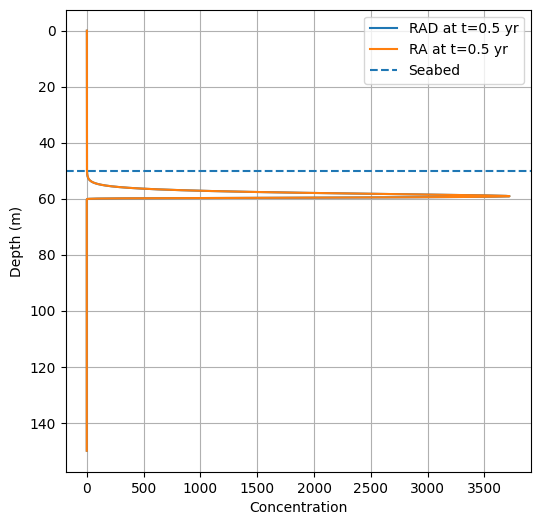

Maximum absolute error between RAD and RA at t=5.0 yr: 8.888e-03


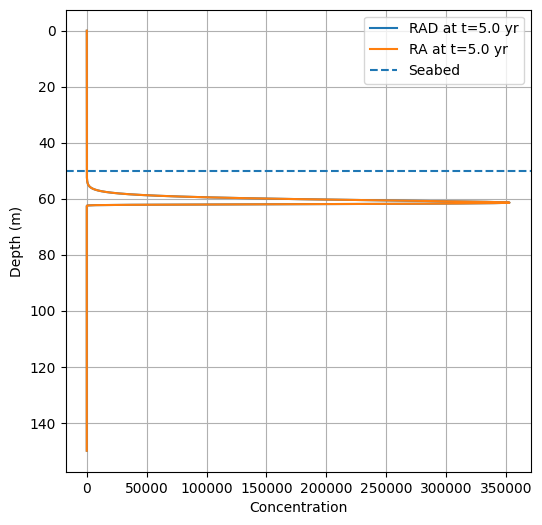

Maximum absolute error between RAD and RA at t=50.0 yr: 5.098e-01


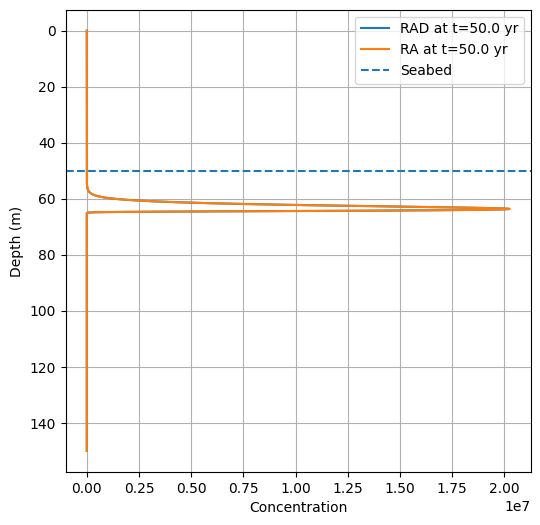

Maximum absolute error between RAD and RA at t=200.0 yr: 1.841e+00


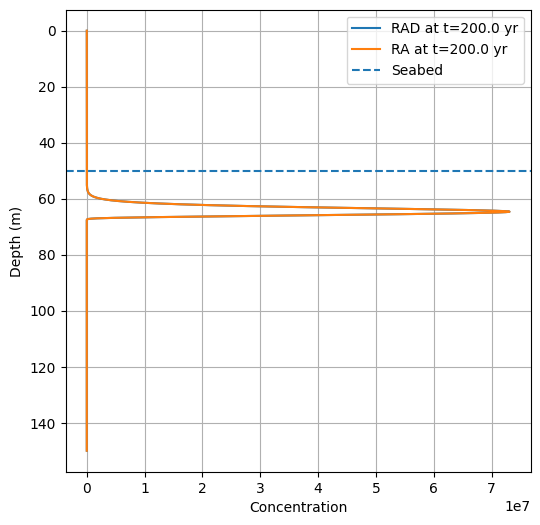

In [10]:
# step length
#Dz = L/(Nx-1)
u = 10**(-2)+(3.66*10**4)/(1+np.exp(z-50))
t_final = [0.5,5,50,200] 

for i in range(len(t_final)):
    time_steps = math.ceil(t_final[i] / dt)
    dt = t_final[i] / time_steps  # end exactly at t_final
    b = np.zeros_like(z)
    b = b_solver(b, alpha, kappa, A_st, Dz,time_steps,u,dt)
    A, B1 = solve_pde_flux_form(z, Dz, dt, time_steps, Nx, Da, alpha, D1, u, kappa, IC_B)
    error = np.max(np.abs(B1 - b))
    print(f"Maximum absolute error between RAD and RA at t={t_final[i]:.1f} yr: {error:.3e}")
    plt.figure(figsize=(6,6))
    plt.plot(B1, z, label='RAD at t={:.1f} yr'.format(t_final[i]))
    plt.plot(b, z, label='RA at t={:.1f} yr'.format(t_final[i]))
    #plt.plot( A,z, label='A')
    plt.axhline(y=50, linestyle='--',label="Seabed")
    plt.gca().invert_yaxis()
    plt.xlabel("Concentration")
    plt.ylabel("Depth (m)")
    #plt.title("Concentration profiles at t={:.1f} yr\nMax Error: {:.3e}".format(    t_final[i], error))
    plt.legend()
    plt.grid()
    plt.show()



In [11]:
print(f"Maximum absolute error between RAD and RA: {error:.3e}")

Maximum absolute error between RAD and RA: 1.841e+00
